<a href="https://colab.research.google.com/github/RonGopal/intro_to_AI/blob/main/FinalProject5rrg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [25]:
newsgroups = fetch_20newsgroups(subset='train')

In [26]:
print("Number of documents:", len(newsgroups.data))
print("Number of categories:", len(newsgroups.target_names))
print("Category names:", newsgroups.target_names)

Number of documents: 11314
Number of categories: 20
Category names: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [27]:
for i in range(3):
    print(f"\n--- Example Document {i} ---\n")
    print(newsgroups.data[i][:500])  # print first 500 chars


--- Example Document 0 ---

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a m

--- Example Document 1 ---

From: guykuo@carson.u.washington.edu (Guy Kuo)
Subject: SI Clock Poll - Final Call
Summary: Final call for SI clock reports
Keywords: SI,acceleration,clock,upgrade
Article-I.D.: shelley.1qvfo9INNc3s
Organization: University of Washington
Lines: 11
NNTP-Posting-Host: carson.u.washington.edu

A fair number of brave souls who upgraded their SI clock oscillator have
shared their experiences for this poll. Please send a brief message detailin

In [28]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.5)

X = vectorizer.fit_transform(newsgroups.data)

print("\nTF-IDF matrix shape:", X.shape)
print("Number of documents:", X.shape[0])
print("Number of features (words):", X.shape[1])

print("\nSample feature names:", vectorizer.get_feature_names_out()[:20])


TF-IDF matrix shape: (11314, 129791)
Number of documents: 11314
Number of features (words): 129791

Sample feature names: ['00' '000' '0000' '00000' '000000' '00000000' '0000000004' '0000000005'
 '00000000b' '00000001' '00000001b' '0000000667' '00000010' '00000010b'
 '00000011' '00000011b' '0000001200' '00000074' '00000093' '000000e5']


In [29]:
K = 5  # number of clusters
kmeans = KMeans(n_clusters=K, random_state=42)
clusters = kmeans.fit_predict(X)

print("\nCluster assignments:", clusters[:20])
print("\nDocuments per cluster:")
print(pd.Series(clusters).value_counts())


Cluster assignments: [3 1 1 3 3 3 3 1 1 1 3 2 3 4 3 2 1 3 3 1]

Documents per cluster:
3    5662
1    2339
2    2010
4    1117
0     186
Name: count, dtype: int64


In [34]:
def top_words_per_cluster(model, vectorizer, n_words=15):
    terms = vectorizer.get_feature_names_out()
    order_centroids = model.cluster_centers_.argsort()[:, ::-1]

    for i in range(model.n_clusters):
        print(f"\nCluster {i} top words:")
        top_terms = [terms[ind] for ind in order_centroids[i, :n_words]]
        print(top_terms)

In [35]:
top_words_per_cluster(kmeans, vectorizer)


Cluster 0 top words:
['ohio', 'geb', 'pitt', 'banks', 'gordon', 'magnus', 'state', 'acs', 'cs', 'shameful', 'n3jxp', 'chastity', 'dsl', 'cadre', 'skepticism']

Cluster 1 top words:
['windows', 'drive', 'card', 'com', 'dos', 'use', 'scsi', 'file', 'window', 'thanks', 'mac', 'university', 'problem', 'help', 'pc']

Cluster 2 top words:
['god', 'people', 'com', 'don', 'think', 'jesus', 'government', 'key', 'just', 'say', 'believe', 'like', 'article', 'israel', 'know']

Cluster 3 top words:
['com', 'article', 'university', 'posting', 'host', 'nntp', 'ca', 'like', 'just', 'distribution', 'don', 'know', 'car', 'cs', 'new']

Cluster 4 top words:
['nasa', 'team', 'game', 'ca', 'space', 'year', 'toronto', 'hockey', 'gov', 'games', 'players', 'henry', 'play', 'season', 'article']


In [32]:
for cluster_id in range(K):
    print(f"\n\n==============================")
    print(f"Example documents from Cluster {cluster_id}")
    print("==============================")

    idx = np.where(clusters == cluster_id)[0][:2]  # first 2 docs
    for i in idx:
        print("\n--- Document ---\n")
        print(newsgroups.data[i][:500])



Example documents from Cluster 0

--- Document ---

From: geb@cs.pitt.edu (Gordon Banks)
Subject: Re: tuberculosis
Reply-To: geb@cs.pitt.edu (Gordon Banks)
Organization: Univ. of Pittsburgh Computer Science
Lines: 20

In article <1993Mar25.020646.852@news.columbia.edu> jhl14@cunixa.cc.columbia.edu (Jonathan H. Lin) writes:
>I was wondering what steps are being taken to prevent the spread of
>multi-drug resistant tuberculosis.  I've heard that some places are
>thinking of incarcerating those with the disease.  Doesn't this violate
>the civil right

--- Document ---

From: stamber@rainbow.ecn.purdue.edu (Kevin L. Stamber)
Subject: Re: How difficult is it to get Penguin tickets?
Organization: Purdue University Engineering Computer Network
Lines: 27

In article <1993Apr18.201811.28965@magnus.acs.ohio-state.edu>, dmoney@magnus.acs.ohio-state.edu (Dean R Money) writes:
> The subject line says it all.  Is it terribly difficult to get tickets
> to Penguins games, especially now that they are

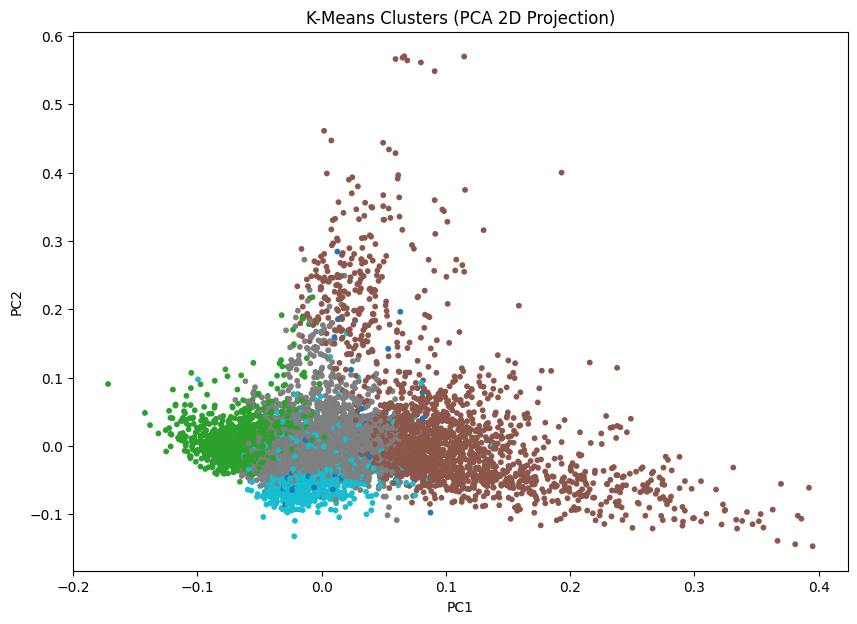

In [33]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', s=10)
plt.title("K-Means Clusters (PCA 2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()